# Notebook 3 of 4 — Stage 6: Model Development (Baseline Models)

## Employee Attrition Prediction

This notebook continues the employee attrition prediction project after completing Exploratory Data Analysis (`01_EDA.ipynb`) and data preprocessing and feature engineering (`02_Preprocessing_FeatureEngineering .ipynb`).

The main objective is to develop machine learning classification models that can predict whether an employee is likely to leave the company based on the available employee-related features.

---

## Stage 6 — Model Development

In this stage, multiple machine learning algorithms are developed and compared instead of relying on a single model.

The following classification algorithms are investigated:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest

The models are trained as baseline models (default settings) and evaluated using suitable classification metrics. Stratified 5-fold cross-validation is used to evaluate how consistently each model performs, and the untouched test set gives an independent check.

Scaled datasets are used for algorithms that are sensitive to differences in feature magnitude (Logistic Regression, KNN), while unscaled datasets are used for tree-based algorithms (Decision Tree, Random Forest).

Hyperparameter tuning, feature selection and final model selection (Stage 7) are carried out in `04_ModelOptimization.ipynb`.

## 1. Import Required Libraries

The following libraries are used for data handling, visualization, machine learning model development, model evaluation, cross-validation and model optimization.

A fixed random state is used where applicable so that the experiments can be reproduced consistently.

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Cross-validation
from sklearn.model_selection import StratifiedKFold, cross_validate

# Fixed random state for reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Prepared Training and Testing Data

The datasets prepared during Stage 4 are loaded directly for model development. The existing train-test split is retained to maintain consistency with the preprocessing stage and to avoid unnecessary changes to the prepared data.

Two versions of the feature datasets are available:

- **Scaled datasets** – used for models that are sensitive to feature magnitude, such as Logistic Regression and K-Nearest Neighbors.
- **Unscaled datasets** – used for tree-based models such as Decision Tree and Random Forest, which generally do not require feature scaling.

The target variable is `LeftCompany`, which represents employee attrition.

In [2]:
# Load unscaled feature datasets
X_train_unscaled = pd.read_csv("../processed_data/X_train_unscaled.csv")
X_test_unscaled = pd.read_csv("../processed_data/X_test_unscaled.csv")

# Load scaled feature datasets
X_train_scaled = pd.read_csv("../processed_data/X_train_scaled.csv")
X_test_scaled = pd.read_csv("../processed_data/X_test_scaled.csv")

# Load target datasets
y_train = pd.read_csv("../processed_data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../processed_data/y_test.csv").squeeze("columns")

print("Datasets loaded successfully.")

print("\nDataset Shapes:")
print("X_train_unscaled :", X_train_unscaled.shape)
print("X_test_unscaled  :", X_test_unscaled.shape)
print("X_train_scaled   :", X_train_scaled.shape)
print("X_test_scaled    :", X_test_scaled.shape)
print("y_train          :", y_train.shape)
print("y_test           :", y_test.shape)

Datasets loaded successfully.

Dataset Shapes:
X_train_unscaled : (4000, 41)
X_test_unscaled  : (1000, 41)
X_train_scaled   : (4000, 41)
X_test_scaled    : (1000, 41)
y_train          : (4000,)
y_test           : (1000,)


## 3. Data Integrity and Target Distribution Check

Before training the machine learning models, the prepared datasets are checked to confirm that the training and testing data are consistent and suitable for modelling.

The following checks are performed:

- Confirm that scaled and unscaled datasets contain the same features.
- Check for missing values.
- Check for infinite values.
- Confirm the target classes.
- Examine the class distribution in the training and testing datasets.

Checking the target distribution is particularly important because a class imbalance can make accuracy alone misleading. Therefore, multiple evaluation metrics such as precision, recall, F1-score and ROC-AUC will be considered during model evaluation.

In [3]:
# Check whether scaled and unscaled datasets contain the same columns
print("Same training columns:",
      list(X_train_scaled.columns) == list(X_train_unscaled.columns))

print("Same testing columns:",
      list(X_test_scaled.columns) == list(X_test_unscaled.columns))

# Check missing values
print("\nMissing Values:")
print("X_train_unscaled:", X_train_unscaled.isnull().sum().sum())
print("X_test_unscaled :", X_test_unscaled.isnull().sum().sum())
print("X_train_scaled  :", X_train_scaled.isnull().sum().sum())
print("X_test_scaled   :", X_test_scaled.isnull().sum().sum())
print("y_train         :", y_train.isnull().sum())
print("y_test          :", y_test.isnull().sum())

# Check infinite values only in numerical columns
print("\nInfinite Values:")

for name, dataset in {
    "X_train_unscaled": X_train_unscaled,
    "X_test_unscaled": X_test_unscaled,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled
}.items():
    
    numeric_data = dataset.select_dtypes(include=np.number)
    infinite_count = np.isinf(numeric_data.to_numpy()).sum()
    
    print(f"{name}: {infinite_count}")

# Display target classes
print("\nTarget Classes:")
print(sorted(y_train.unique()))

# Training target distribution
train_distribution = pd.DataFrame({
    "Count": y_train.value_counts().sort_index(),
    "Percentage": y_train.value_counts(normalize=True).sort_index() * 100
})

# Testing target distribution
test_distribution = pd.DataFrame({
    "Count": y_test.value_counts().sort_index(),
    "Percentage": y_test.value_counts(normalize=True).sort_index() * 100
})

print("\nTraining Target Distribution:")
display(train_distribution.round(2))

print("\nTesting Target Distribution:")
display(test_distribution.round(2))

Same training columns: True
Same testing columns: True

Missing Values:
X_train_unscaled: 0
X_test_unscaled : 0
X_train_scaled  : 0
X_test_scaled   : 0
y_train         : 0
y_test          : 0

Infinite Values:
X_train_unscaled: 0
X_test_unscaled: 0
X_train_scaled: 0
X_test_scaled: 0

Target Classes:
[np.int64(0), np.int64(1)]

Training Target Distribution:


,Count,Percentage
LeftCompany,,
0,2516,62.9
1,1484,37.1



Testing Target Distribution:


,Count,Percentage
LeftCompany,,
0,629,62.9
1,371,37.1


## 4. Validation and Evaluation Strategy

A stratified 5-fold cross-validation strategy is used to evaluate the baseline models on the training data.

Stratified cross-validation maintains approximately the same class distribution in each fold. This is suitable for the employee attrition dataset because the target variable is moderately imbalanced, with approximately 62.9% of employees in the non-attrition class and 37.1% in the attrition class.

Five folds provide multiple validation results while still leaving sufficient data for training in each iteration.

The following performance metrics are used:

- **Accuracy** – the proportion of all predictions that are correct.
- **Precision** – the proportion of predicted attrition cases that are actually attrition cases.
- **Recall** – the proportion of actual attrition cases correctly identified by the model.
- **F1-score** – the harmonic mean of precision and recall.
- **ROC-AUC** – measures the model's ability to distinguish between employees who leave and employees who stay across different classification thresholds.

Because the target classes are not perfectly balanced, model selection will not be based on accuracy alone. Particular attention will be given to recall, F1-score and ROC-AUC together with the other evaluation results.

The final test dataset is kept separate from cross-validation and is used to evaluate how well the trained models generalize to unseen data.

In [4]:
# Define stratified 5-fold cross-validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics used during cross-validation
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

print("Validation strategy: Stratified 5-Fold Cross-Validation")
print("Evaluation metrics:", list(scoring_metrics.keys()))

Validation strategy: Stratified 5-Fold Cross-Validation
Evaluation metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


## 5. Baseline Model Development

### 5.1 Logistic Regression

Logistic Regression is used as the first baseline classification model. It is suitable for binary classification problems such as predicting whether an employee will leave or stay.

The scaled feature dataset is used because Logistic Regression can be affected by differences in feature magnitude, and scaling also supports more stable coefficient optimization.

The model is first evaluated using stratified 5-fold cross-validation on the training data. It is then fitted using the complete training dataset and evaluated on the unseen test dataset.

Default model behaviour is retained as much as possible at this baseline stage so that later optimization can be compared against an initial reference model.

In [5]:
# Create baseline Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Perform stratified 5-fold cross-validation
logistic_cv_results = cross_validate(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

# Display mean cross-validation results
print("Logistic Regression - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = logistic_cv_results[f"test_{metric}"]
    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Logistic Regression - 5-Fold Cross-Validation Results

Accuracy  : 0.6998 ± 0.0093
Precision : 0.6421 ± 0.0212
Recall    : 0.4319 ± 0.0207
F1        : 0.5161 ± 0.0172
Roc_auc   : 0.7032 ± 0.0091


#### Cross-Validation Observation

The baseline Logistic Regression model produced an average cross-validation accuracy of approximately 0.700 and an ROC-AUC of approximately 0.703.

The model achieved a precision of approximately 0.642 but a lower recall of approximately 0.432. This indicates that although most of the employees predicted as attrition cases were correct, the model failed to identify a considerable proportion of employees who actually left.

The resulting F1-score was approximately 0.516, reflecting the imbalance between precision and recall.

The small standard deviations across the five folds (below 0.022 for every metric) indicate that the model produced consistent validation results. These results are used as the baseline for comparison with the other classification algorithms.

### 5.1.1 Logistic Regression – Test Set Evaluation

After cross-validation, the Logistic Regression model is trained using the complete scaled training dataset.

The trained model is then evaluated using the unseen test dataset. The test dataset was not used for fitting the model or during cross-validation, allowing it to provide an independent estimate of how well the model generalizes to unseen employee records.

The same evaluation metrics used during cross-validation are calculated for the test predictions.

In [6]:
# Train Logistic Regression using the complete training dataset
logistic_model.fit(X_train_scaled, y_train)

# Generate class predictions for the unseen test dataset
logistic_predictions = logistic_model.predict(X_test_scaled)

# Generate probability estimates for the positive class (LeftCompany = 1)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate test performance metrics
logistic_test_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_test_precision = precision_score(y_test, logistic_predictions)
logistic_test_recall = recall_score(y_test, logistic_predictions)
logistic_test_f1 = f1_score(y_test, logistic_predictions)
logistic_test_auc = roc_auc_score(y_test, logistic_probabilities)

print("Logistic Regression - Test Set Results\n")
print(f"Accuracy : {logistic_test_accuracy:.4f}")
print(f"Precision: {logistic_test_precision:.4f}")
print(f"Recall   : {logistic_test_recall:.4f}")
print(f"F1-score : {logistic_test_f1:.4f}")
print(f"ROC-AUC  : {logistic_test_auc:.4f}")

Logistic Regression - Test Set Results

Accuracy : 0.6910
Precision: 0.6250
Recall   : 0.4178
F1-score : 0.5008
ROC-AUC  : 0.6952


### 5.1.2 Logistic Regression – Confusion Matrix

A confusion matrix is used to examine the types of predictions made by the Logistic Regression model.

For the employee attrition problem:

- **True Negative (TN):** Employee stayed and the model correctly predicted stay.
- **False Positive (FP):** Employee stayed but the model predicted attrition.
- **False Negative (FN):** Employee left but the model predicted stay.
- **True Positive (TP):** Employee left and the model correctly predicted attrition.

False negatives are particularly important in this problem because they represent employees who actually leave but are not identified by the prediction model.

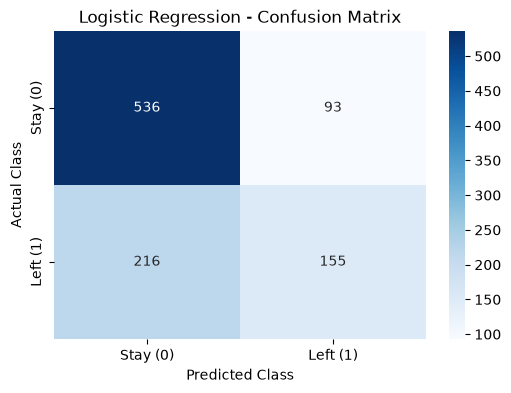

In [7]:
# Calculate confusion matrix
logistic_cm = confusion_matrix(y_test, logistic_predictions)

# Display confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Left (1)"],
    yticklabels=["Stay (0)", "Left (1)"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

#### Logistic Regression Test Set Observation

The Logistic Regression confusion matrix shows that the model correctly classified 536 employees who stayed and 155 employees who left the company.

However, the model produced 216 false negatives, meaning that 216 employees who actually left the company were incorrectly predicted as employees who would stay. It also produced 93 false positives, where employees who stayed were incorrectly predicted as attrition cases.

The relatively high number of false negatives is an important limitation for the employee attrition prediction problem because the model fails to identify a considerable number of actual attrition cases. This is reflected in the low test recall (0.418).

The test results (accuracy 0.691, F1 0.501, ROC-AUC 0.695) are very close to the cross-validation results, so the model generalises consistently. Its limitation is underfitting, not overfitting: Logistic Regression can only draw a linear decision boundary, while attrition in this dataset depends on a few features (satisfaction, appraisal, work-life balance, overtime) that may combine in non-linear ways.

These baseline results are compared with the other machine learning algorithms to determine whether another model can identify attrition cases more effectively while maintaining reasonable overall performance.

### 5.2 K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a classification algorithm that predicts the class of a new observation based on the classes of its nearest observations in the feature space.

KNN is included as a baseline model because it provides a different modelling approach from Logistic Regression. While Logistic Regression learns a linear decision boundary, KNN makes predictions based on local similarity between observations.

The scaled dataset is used for KNN because the algorithm relies on distance calculations. Without scaling, features with larger numerical ranges could have an unfair influence on the calculated distances.

A baseline KNN model is first evaluated using the same stratified 5-fold cross-validation strategy and evaluation metrics used for Logistic Regression. This ensures that the models are compared under a consistent validation procedure.

In [8]:
# Create baseline KNN model
knn_model = KNeighborsClassifier()

# Perform stratified 5-fold cross-validation
knn_cv_results = cross_validate(
    knn_model,
    X_train_scaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

# Display mean cross-validation results
print("KNN - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = knn_cv_results[f"test_{metric}"]
    
    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

KNN - 5-Fold Cross-Validation Results

Accuracy  : 0.6440 ± 0.0054
Precision : 0.5306 ± 0.0126
Recall    : 0.3571 ± 0.0125
F1        : 0.4266 ± 0.0059
Roc_auc   : 0.6149 ± 0.0056


#### KNN Cross-Validation Observation

The baseline KNN model (K = 5) achieved an average cross-validation accuracy of approximately 0.644 and an ROC-AUC of approximately 0.615.

The model achieved a precision of approximately 0.531 and a recall of approximately 0.357. The low recall indicates that the baseline KNN model failed to identify most actual employee attrition cases. The resulting F1-score was approximately 0.427.

Compared with the baseline Logistic Regression model, KNN produced lower values for accuracy, precision, recall, F1-score and ROC-AUC under the same cross-validation strategy. Therefore, the default KNN configuration is less effective on this dataset than the baseline Logistic Regression model.

A likely reason is that KNN gives **every feature equal weight** in its distance calculation. After scaling, all 41 features contribute equally, but the EDA showed that only about four of them (JobSatisfaction, AppraisalRating, WorkLifeBalance, DoesOvertime) carry real signal. The remaining features add noise to the distances, so the "nearest neighbours" of an employee are often not genuinely similar in the ways that matter for attrition (the *curse of dimensionality*).

The effect of different K values and weighting methods is checked in Stage 7 (`04_ModelOptimization.ipynb`, Section 8).

### 5.2.1 KNN – Test Set Evaluation

After cross-validation, the baseline KNN model is trained using the complete scaled training dataset and evaluated on the unseen test dataset.

The scaled data is used because KNN relies on distance calculations between observations. The test evaluation provides an independent measure of how well the baseline KNN model generalizes to previously unseen employee records.

In [9]:
# Train KNN using the complete training dataset
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
knn_predictions = knn_model.predict(X_test_scaled)

# Generate probabilities for the positive class
knn_probabilities = knn_model.predict_proba(X_test_scaled)[:, 1]

# Calculate test performance metrics
knn_test_accuracy = accuracy_score(y_test, knn_predictions)
knn_test_precision = precision_score(y_test, knn_predictions)
knn_test_recall = recall_score(y_test, knn_predictions)
knn_test_f1 = f1_score(y_test, knn_predictions)
knn_test_auc = roc_auc_score(y_test, knn_probabilities)

print("KNN - Test Set Results\n")
print(f"Accuracy : {knn_test_accuracy:.4f}")
print(f"Precision: {knn_test_precision:.4f}")
print(f"Recall   : {knn_test_recall:.4f}")
print(f"F1-score : {knn_test_f1:.4f}")
print(f"ROC-AUC  : {knn_test_auc:.4f}")

KNN - Test Set Results

Accuracy : 0.6410
Precision: 0.5231
Recall   : 0.3666
F1-score : 0.4311
ROC-AUC  : 0.6200


### 5.2.2 KNN – Confusion Matrix

The confusion matrix is used to examine the correct and incorrect predictions produced by the baseline KNN model. Particular attention is given to false negatives because these represent employees who actually left the company but were predicted to stay.

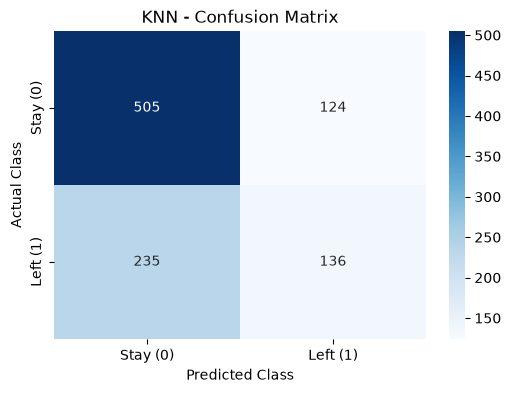

In [10]:
# Calculate KNN confusion matrix
knn_cm = confusion_matrix(y_test, knn_predictions)

# Display confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Left (1)"],
    yticklabels=["Stay (0)", "Left (1)"]
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

#### KNN Test Set Observation

The KNN confusion matrix shows that the model correctly classified 505 employees who stayed and 136 employees who left the company.

However, the model produced 235 false negatives, meaning that 235 employees who actually left were incorrectly predicted as employees who would stay. It also produced 124 false positives.

Compared with the baseline Logistic Regression model, KNN produced more false negatives, more false positives and fewer true positives. This is consistent with the lower recall observed during cross-validation and indicates that the baseline KNN model has the greatest difficulty identifying employees who actually leave.

The test results (accuracy 0.641, F1 0.431) are close to the cross-validation results, so the weak performance is consistent rather than caused by an unlucky split. Different values for the number of neighbours and the weighting method are checked during Stage 7.

### 5.3 Decision Tree

A Decision Tree is a supervised machine learning algorithm that performs classification by repeatedly splitting the data according to feature values. The objective of these splits is to create groups that increasingly separate the target classes.

Decision Trees can capture non-linear relationships and interactions between employee characteristics without requiring a linear relationship between the features and employee attrition.

Unlike Logistic Regression and KNN, Decision Trees do not rely on feature distances or coefficient optimization. Therefore, feature scaling is generally not required. For this reason, the unscaled training and testing datasets are used for the Decision Tree model.

A baseline Decision Tree is first evaluated using the same stratified 5-fold cross-validation strategy and performance metrics used for the previous models. Hyperparameter tuning will be performed later during Stage 7.

In [11]:
# Create baseline Decision Tree model
decision_tree_model = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Perform stratified 5-fold cross-validation
decision_tree_cv_results = cross_validate(
    decision_tree_model,
    X_train_unscaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

# Display mean cross-validation results
print("Decision Tree - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = decision_tree_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Decision Tree - 5-Fold Cross-Validation Results

Accuracy  : 0.6675 ± 0.0106
Precision : 0.5510 ± 0.0160
Recall    : 0.5654 ± 0.0257
F1        : 0.5577 ± 0.0145
Roc_auc   : 0.6466 ± 0.0103


#### Decision Tree Cross-Validation Observation

The baseline Decision Tree achieved an average cross-validation accuracy of approximately 0.668 and an ROC-AUC of approximately 0.647.

The model achieved a precision of approximately 0.551 and a recall of approximately 0.565, resulting in an F1-score of approximately 0.558.

Compared with Logistic Regression and KNN, the Decision Tree achieved a higher recall and F1-score, indicating that it identified a larger proportion of actual employee attrition cases. However, its accuracy, precision and ROC-AUC were lower than those of Logistic Regression.

These results demonstrate an important trade-off between the models. Logistic Regression currently provides stronger overall discrimination and precision, while the Decision Tree identifies a greater proportion of actual attrition cases. Therefore, model performance should be assessed using multiple metrics rather than accuracy alone.

The baseline Decision Tree is unrestricted and may be susceptible to overfitting. Its complexity-related hyperparameters will therefore be investigated during Stage 7 model optimization.

### 5.3.1 Decision Tree – Test Set Evaluation

After cross-validation, the baseline Decision Tree is trained using the complete unscaled training dataset and evaluated using the unseen test dataset.

The unscaled dataset is used because Decision Trees make threshold-based feature splits and therefore do not generally require feature scaling.

The test results are compared with the cross-validation results to assess whether the model generalizes consistently to unseen employee records.

In [12]:
# Train Decision Tree on complete training dataset
decision_tree_model.fit(X_train_unscaled, y_train)

# Generate test predictions
decision_tree_predictions = decision_tree_model.predict(X_test_unscaled)

# Generate probabilities for the positive class
decision_tree_probabilities = decision_tree_model.predict_proba(
    X_test_unscaled
)[:, 1]

# Calculate test metrics
decision_tree_test_accuracy = accuracy_score(
    y_test, decision_tree_predictions
)

decision_tree_test_precision = precision_score(
    y_test, decision_tree_predictions
)

decision_tree_test_recall = recall_score(
    y_test, decision_tree_predictions
)

decision_tree_test_f1 = f1_score(
    y_test, decision_tree_predictions
)

decision_tree_test_auc = roc_auc_score(
    y_test, decision_tree_probabilities
)

print("Decision Tree - Test Set Results\n")
print(f"Accuracy : {decision_tree_test_accuracy:.4f}")
print(f"Precision: {decision_tree_test_precision:.4f}")
print(f"Recall   : {decision_tree_test_recall:.4f}")
print(f"F1-score : {decision_tree_test_f1:.4f}")
print(f"ROC-AUC  : {decision_tree_test_auc:.4f}")

Decision Tree - Test Set Results

Accuracy : 0.6710
Precision: 0.5525
Recall   : 0.5957
F1-score : 0.5733
ROC-AUC  : 0.6556


### 5.3.2 Decision Tree – Confusion Matrix

The confusion matrix is used to examine the types of correct and incorrect predictions produced by the baseline Decision Tree.

Particular attention is given to false negatives because these represent employees who actually left the company but were incorrectly predicted to stay.

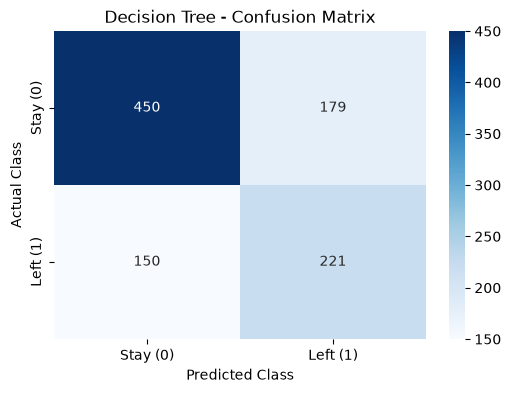

In [13]:
# Calculate Decision Tree confusion matrix
decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

# Display confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Left (1)"],
    yticklabels=["Stay (0)", "Left (1)"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

#### Decision Tree Test Set Observation

The Decision Tree correctly classified 450 employees who stayed and 221 employees who left the company. It produced 179 false positives and 150 false negatives.

Compared with Logistic Regression and KNN, the Decision Tree identified more actual attrition cases and produced fewer false negatives. This supports the higher recall observed during cross-validation.

However, the Decision Tree also produced considerably more false positives. This demonstrates a trade-off between identifying a greater proportion of employees who leave and incorrectly classifying employees who actually stay.

The results are consistent with the cross-validation findings, where the Decision Tree showed stronger recall and F1-score but lower precision and overall discrimination than Logistic Regression. The unrestricted baseline tree may also be susceptible to overfitting, which will be investigated during model optimization.

### 5.4 Random Forest

Random Forest is an ensemble classification algorithm that combines predictions from multiple Decision Trees.

Instead of relying on a single tree, Random Forest trains many trees using different samples of the training data and subsets of features. The predictions from these trees are then combined to produce the final classification.

This approach can reduce the instability and overfitting associated with an individual Decision Tree and can capture complex and non-linear relationships between employee characteristics and attrition.

Like Decision Trees, Random Forest does not rely on distance calculations and generally does not require feature scaling. Therefore, the unscaled training and testing datasets are used.

A baseline Random Forest model is evaluated using the same stratified 5-fold cross-validation strategy and evaluation metrics used for the other baseline models.

In [14]:
# Create baseline Random Forest model
random_forest_model = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Perform stratified 5-fold cross-validation
random_forest_cv_results = cross_validate(
    random_forest_model,
    X_train_unscaled,
    y_train,
    cv=cv_strategy,
    scoring=scoring_metrics,
    n_jobs=-1
)

# Display mean cross-validation results
print("Random Forest - 5-Fold Cross-Validation Results\n")

for metric in scoring_metrics:
    scores = random_forest_cv_results[f"test_{metric}"]

    print(
        f"{metric.capitalize():10s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Random Forest - 5-Fold Cross-Validation Results

Accuracy  : 0.7963 ± 0.0071
Precision : 0.8167 ± 0.0153
Recall    : 0.5822 ± 0.0338
F1        : 0.6790 ± 0.0196
Roc_auc   : 0.7612 ± 0.0160


#### Random Forest Cross-Validation Observation

The baseline Random Forest model achieved an average cross-validation accuracy of approximately 0.796 and an ROC-AUC of approximately 0.761.

The model achieved a precision of approximately 0.817 and a recall of approximately 0.582, resulting in an F1-score of approximately 0.679.

Among the four baseline models evaluated so far, Random Forest produced the highest mean cross-validation values for accuracy, precision, recall, F1-score and ROC-AUC. It also showed relatively small variation across the five validation folds.

Compared with the single Decision Tree, Random Forest achieved higher accuracy and precision while also slightly improving recall. This suggests that combining multiple trees provides more effective and stable predictions on this dataset than relying on a single unrestricted Decision Tree.

However, final model selection will not be made using the baseline cross-validation results alone. Test-set performance and the results of model optimization in Stage 7 will also be considered.

### 5.4.1 Random Forest – Test Set Evaluation

After cross-validation, the baseline Random Forest model is trained using the complete unscaled training dataset and evaluated on the unseen test dataset.

The test-set evaluation is used to examine whether the strong cross-validation performance is maintained when the model is applied to employee records that were not used during model training or cross-validation.

In [15]:
# Train Random Forest using the complete training dataset
random_forest_model.fit(X_train_unscaled, y_train)

# Generate predictions
random_forest_predictions = random_forest_model.predict(
    X_test_unscaled
)

# Generate probabilities for the positive class
random_forest_probabilities = random_forest_model.predict_proba(
    X_test_unscaled
)[:, 1]

# Calculate test metrics
random_forest_test_accuracy = accuracy_score(
    y_test, random_forest_predictions
)

random_forest_test_precision = precision_score(
    y_test, random_forest_predictions
)

random_forest_test_recall = recall_score(
    y_test, random_forest_predictions
)

random_forest_test_f1 = f1_score(
    y_test, random_forest_predictions
)

random_forest_test_auc = roc_auc_score(
    y_test, random_forest_probabilities
)

print("Random Forest - Test Set Results\n")
print(f"Accuracy : {random_forest_test_accuracy:.4f}")
print(f"Precision: {random_forest_test_precision:.4f}")
print(f"Recall   : {random_forest_test_recall:.4f}")
print(f"F1-score : {random_forest_test_f1:.4f}")
print(f"ROC-AUC  : {random_forest_test_auc:.4f}")

Random Forest - Test Set Results

Accuracy : 0.7850
Precision: 0.7932
Recall   : 0.5687
F1-score : 0.6625
ROC-AUC  : 0.7546


### 5.4.2 Random Forest – Confusion Matrix

The confusion matrix is used to examine the correct and incorrect classifications produced by the baseline Random Forest model.

The numbers of true positives, true negatives, false positives and false negatives are examined to better understand the model's performance beyond the overall evaluation metrics.

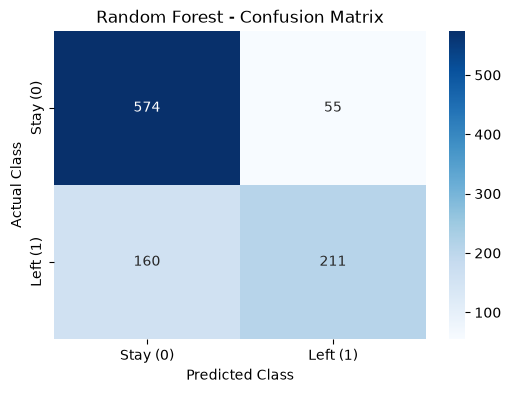

In [16]:
# Calculate Random Forest confusion matrix
random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

# Display confusion matrix
plt.figure(figsize=(6, 4))

sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay (0)", "Left (1)"],
    yticklabels=["Stay (0)", "Left (1)"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

#### Random Forest Test Set Observation

The baseline Random Forest correctly classified 574 employees who stayed and 211 employees who left the company. It produced 55 false positives and 160 false negatives.

Compared with Logistic Regression and KNN, Random Forest identified more actual attrition cases while also producing fewer false-positive predictions. Compared with the single Decision Tree, Random Forest produced substantially fewer false positives while maintaining a relatively high number of correctly identified attrition cases.

These results are consistent with the strong cross-validation performance of Random Forest and suggest that combining multiple Decision Trees provides more stable and effective predictions than relying on a single unrestricted tree for this dataset.

However, these are baseline results. Hyperparameter optimization and further modelling experiments will be conducted during Stage 7 before the final model is selected.

## 6. Baseline Model Comparison

The four baseline classification models are compared systematically using both cross-validation performance and unseen test-set performance.

Cross-validation provides an estimate of how consistently each model performs across different subsets of the training data, while the test set provides an independent evaluation using previously unseen observations.

The comparison considers accuracy, precision, recall, F1-score and ROC-AUC rather than relying on a single metric. This is particularly important for employee attrition prediction because identifying actual attrition cases is important while excessive false-positive predictions should also be avoided.

In [17]:
# Create baseline model comparison table

baseline_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest"
    ],

    "CV Accuracy": [
        logistic_cv_results["test_accuracy"].mean(),
        knn_cv_results["test_accuracy"].mean(),
        decision_tree_cv_results["test_accuracy"].mean(),
        random_forest_cv_results["test_accuracy"].mean()
    ],

    "CV Precision": [
        logistic_cv_results["test_precision"].mean(),
        knn_cv_results["test_precision"].mean(),
        decision_tree_cv_results["test_precision"].mean(),
        random_forest_cv_results["test_precision"].mean()
    ],

    "CV Recall": [
        logistic_cv_results["test_recall"].mean(),
        knn_cv_results["test_recall"].mean(),
        decision_tree_cv_results["test_recall"].mean(),
        random_forest_cv_results["test_recall"].mean()
    ],

    "CV F1": [
        logistic_cv_results["test_f1"].mean(),
        knn_cv_results["test_f1"].mean(),
        decision_tree_cv_results["test_f1"].mean(),
        random_forest_cv_results["test_f1"].mean()
    ],

    "CV ROC-AUC": [
        logistic_cv_results["test_roc_auc"].mean(),
        knn_cv_results["test_roc_auc"].mean(),
        decision_tree_cv_results["test_roc_auc"].mean(),
        random_forest_cv_results["test_roc_auc"].mean()
    ],

    "Test Accuracy": [
        logistic_test_accuracy,
        knn_test_accuracy,
        decision_tree_test_accuracy,
        random_forest_test_accuracy
    ],

    "Test Precision": [
        logistic_test_precision,
        knn_test_precision,
        decision_tree_test_precision,
        random_forest_test_precision
    ],

    "Test Recall": [
        logistic_test_recall,
        knn_test_recall,
        decision_tree_test_recall,
        random_forest_test_recall
    ],

    "Test F1": [
        logistic_test_f1,
        knn_test_f1,
        decision_tree_test_f1,
        random_forest_test_f1
    ],

    "Test ROC-AUC": [
        logistic_test_auc,
        knn_test_auc,
        decision_tree_test_auc,
        random_forest_test_auc
    ]
})

baseline_comparison.round(4)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.6998,0.6421,0.4319,0.5161,0.7032,0.691,0.6250,0.4178,0.5008,0.6952
1,KNN,0.6440,0.5306,0.3571,0.4266,0.6149,0.641,0.5231,0.3666,0.4311,0.6200
2,Decision Tree,0.6675,0.5510,0.5654,0.5577,0.6466,0.671,0.5525,0.5957,0.5733,0.6556
3,Random Forest,0.7962,0.8167,0.5822,0.6790,0.7612,0.785,0.7932,0.5687,0.6625,0.7546


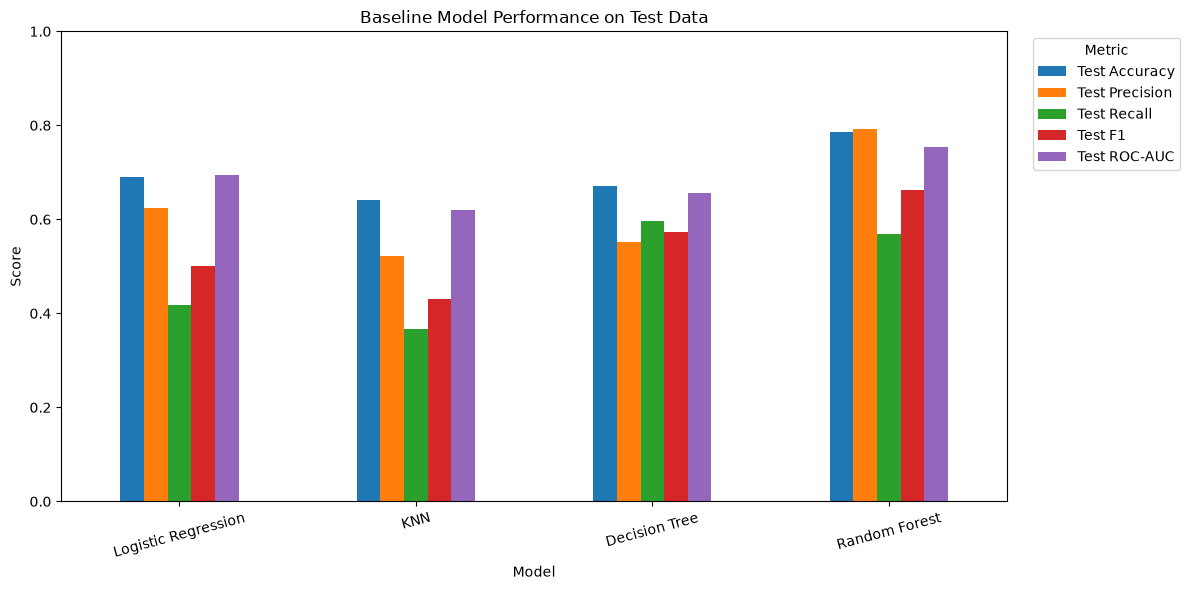

In [18]:
# Compare baseline test performance visually

test_metrics_comparison = baseline_comparison.set_index("Model")[
    [
        "Test Accuracy",
        "Test Precision",
        "Test Recall",
        "Test F1",
        "Test ROC-AUC"
    ]
]

ax = test_metrics_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Performance on Test Data")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.1 Training vs Test Accuracy — Why the Models Differ

To understand *why* some models perform better than others, each baseline model's accuracy on the data it was trained on is compared with its accuracy on the unseen test set.

- A **large gap** (very high training accuracy, much lower test accuracy) means the model has memorised the training data — **overfitting**.
- A **small gap with low scores** on both means the model is too simple to capture the pattern — **underfitting**.

In [19]:
fitted_baselines = {
    "Logistic Regression": (logistic_model, X_train_scaled, X_test_scaled),
    "KNN": (knn_model, X_train_scaled, X_test_scaled),
    "Decision Tree": (decision_tree_model, X_train_unscaled, X_test_unscaled),
    "Random Forest": (random_forest_model, X_train_unscaled, X_test_unscaled)
}

fit_check = pd.DataFrame({
    name: {
        "Training Accuracy": accuracy_score(y_train, model.predict(X_tr)),
        "Test Accuracy": accuracy_score(y_test, model.predict(X_te))
    }
    for name, (model, X_tr, X_te) in fitted_baselines.items()
}).T

fit_check["Gap"] = fit_check["Training Accuracy"] - fit_check["Test Accuracy"]

display(fit_check.round(4))

,Training Accuracy,Test Accuracy,Gap
Logistic Regression,0.7062,0.691,0.0153
KNN,0.7675,0.641,0.1265
Decision Tree,1.0000,0.671,0.3290
Random Forest,1.0000,0.785,0.2150


### 6.2 Baseline Model Comparison — Key Findings

The baseline comparison demonstrates clear differences between the four machine learning algorithms.

**Logistic Regression** provided reasonable overall discrimination (test ROC-AUC 0.695) but low recall (0.418), so many actual attrition cases were missed. Its training and test accuracy are almost the same (gap 0.015): it is not overfitting, it is **underfitting**. A straight-line decision boundary is too simple for this problem.

**KNN** produced the weakest performance across every metric (test F1 0.431). Its training-test gap (0.127) shows it partly memorises local neighbourhoods, and because every feature counts equally in its distance, the many uninformative features dilute the few informative ones.

**Decision Tree** achieved higher recall (0.596) than Logistic Regression and KNN, identifying more employees who actually left, but with lower precision and many more false positives. Its training accuracy of **1.000** against a test accuracy of 0.671 (gap 0.329) is clear evidence of **overfitting**: an unrestricted tree keeps splitting until it memorises every training employee.

**Random Forest** demonstrated the strongest overall baseline performance, with the highest test accuracy (0.785), precision (0.793), F1-score (0.663) and ROC-AUC (0.755). Each of its individual trees also memorises the training data (training accuracy 1.000), but averaging hundreds of different trees, each built on a different bootstrap sample and a random subset of features, cancels out much of the individual trees' errors. This is why its test accuracy is far higher than that of the single tree. The Decision Tree achieved slightly higher test recall, showing that model selection involves a trade-off between performance measures.

The cross-validation and test-set results therefore suggest that Random Forest is a strong candidate for further optimization, and that the main problem of the Decision Tree (overfitting) can be addressed by limiting its complexity. No final model is selected at this stage; Stage 7 investigates hyperparameter tuning and other modelling choices.